Shape: (240, 240, 155)


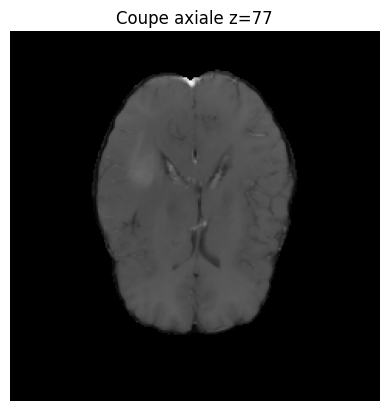

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

path = "Documents\backend_Plateforme_Cancer-main\bin\MRI\MsrGB01_PUI_20110324_0001.nii.gz"
img = nib.load(path)    
data = img.get_fdata()  

print("Shape:", data.shape)  

# Cas 3D (IRM structurelle)
z = data.shape[2] // 2
slice2d = data[:, :, z]

plt.figure()
plt.imshow(slice2d.T, cmap="gray", origin="lower") 
plt.title(f"Coupe axiale z={z}")
plt.axis("off")
plt.show()


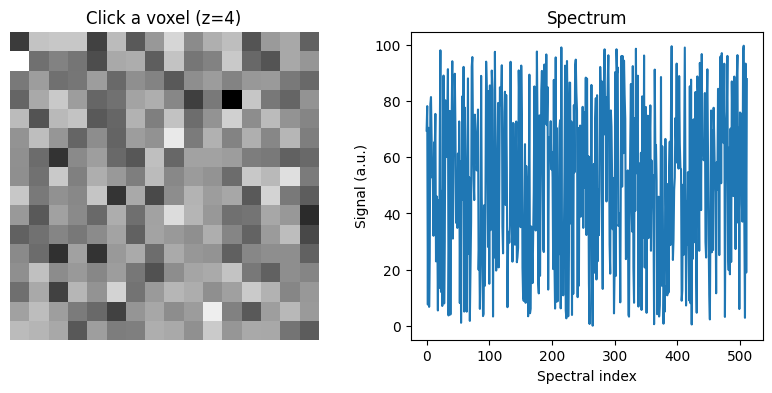

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

img = nib.load("Documents\backend_Plateforme_Cancer-main\bin\MRSI\MsrGB_MRSI_01_PUI_20110324_hsvd_atlas.nii")
data = img.get_fdata()  # (16,16,8,512)

z = data.shape[2] // 2

# Carte pour choisir le voxel (résumé du spectre)
base_map = np.mean(data[:, :, z, :], axis=2)  # (16,16)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))

ax0.imshow(base_map, cmap="gray", origin="lower")
ax0.set_title(f"Click a voxel (z={z})")
ax0.axis("off")

line, = ax1.plot(data[0, 0, z, :])
ax1.set_title("Spectrum")
ax1.set_xlabel("Spectral index")
ax1.set_ylabel("Signal (a.u.)")

def onclick(event):
    if event.inaxes != ax0 or event.xdata is None or event.ydata is None:
        return
    x = int(round(event.xdata))
    y = int(round(event.ydata))
    x = np.clip(x, 0, data.shape[0]-1)
    y = np.clip(y, 0, data.shape[1]-1)

    spec = data[x, y, z, :]
    line.set_ydata(spec)
    ax1.relim()
    ax1.autoscale_view()
    ax1.set_title(f"Spectrum at (x={x}, y={y}, z={z})")
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect("button_press_event", onclick)
plt.show()

In [ ]:
import nibabel as nib
import numpy as np

path_irm = "Documents\backend_Plateforme_Cancer-main\bin\MRI\MsrGB01_PUI_20110324_0001.nii.gz"
img = nib.load(path_irm)
data = img.get_fdata()
print("IRM shape:", data.shape)

X, Y, Z = data.shape
cx, cy, cz = X//2, Y//2, Z//2

sag = data[cx,:,:]
cor = data[:,cy,:]
axi = data[:,:,cz]

print("Sagittal:", sag.shape, "Coronal:", cor.shape, "Axial:", axi.shape)
print("Ranges:", np.min(axi), np.max(axi))


IRM shape: (240, 240, 155)
Sagittal: (240, 155) Coronal: (240, 155) Axial: (240, 240)
Ranges: 0.0 4748.0
